In [64]:
import torch
import torch.nn as nn               #! neural network
import torch.nn.functional as F     #!functions of neural network

In [65]:
# Create a Model Class that inherits nn.Module
class Model(nn.Module):
    # Input Layer (4 features of flower) --> Hidden Layer 1 (numbers of neurons) -->
    # HL2 (numbers od neurons) --> output layer (3 classes of iris flower)
    def __init__(self, in_features=4, h1 = 8, h2 = 9, out_features=3):
        super().__init__()  # instantiate our nn.Module
        self.fc1 = nn.Linear(in_features, h1)       #! fully connected by linear
        self.fc2 = nn.Linear(h1, h2)
        self.out = nn.Linear(h2, out_features)
    
    def forward(self, x):
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = self.out(x)
        return x

In [66]:
# Pick a manual seed for randomization
torch.manual_seed(41)
# Create a instance of model
model = Model()

In [67]:
import pandas as pd
import matplotlib.pyplot as plt


In [68]:
from sklearn.datasets import load_iris

iris = load_iris(as_frame=True)
my_df = iris.frame
my_df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [69]:
# Train Test split X, y
X = my_df.drop('target', axis=1)        #!removes that column, leaving all other columns in X—typically the 
#! input features for a model.
#! - axis=0 (default): rows
#! - axis=1: columns
y = my_df['target']

In [70]:
# Converting this data frames to numpy array
X = X.values
y = y.values

In [71]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=41)

In [72]:
# Convert X feautures to float tensors
X_test = torch.FloatTensor(X_test)
X_train = torch.FloatTensor(X_train)

# Convert y labels to tensors long
y_test = torch.LongTensor(y_test)
y_train = torch.LongTensor(y_train)


In [73]:
# Set the criterion of model to measure the error , how far off the predictions are from our data
criterion = nn.CrossEntropyLoss()

# Choose Adam Optimizer, lr = learning rate (if error doesn't go down after bunch of iterations(epochs), lower our lr)
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)

In [74]:
#! Train our model
# Epochs? (one run thru all the training data in our network)
epochs = 100
losses = []

for i in range(epochs):
    # Go forward and get predictions 
    y_pred = model.forward(X_train)     #Get predicted results
    
    # Measure the loss/error, gonna be high at the first time
    loss = criterion(y_pred, y_train) # predicted values vs y_train 
    
    # Keep track of our losses
    losses.append(loss.detach().numpy())        # Convert our tensor data to default numpy numbers
    
    # Print every 10 epoch
    if i % 10 == 0:
        print(f'Epoch = {i}, and loss is = {loss}')
        
    # Do some back propagation: take the error rate of forward propagation and feed it back thru the network to find tune the weights
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    

Epoch = 0, and loss is = 1.125203251838684
Epoch = 10, and loss is = 1.0097211599349976
Epoch = 20, and loss is = 0.8162347078323364
Epoch = 30, and loss is = 0.585993230342865
Epoch = 40, and loss is = 0.4003389775753021
Epoch = 50, and loss is = 0.26794716715812683
Epoch = 60, and loss is = 0.1796349734067917
Epoch = 70, and loss is = 0.12165626138448715
Epoch = 80, and loss is = 0.08606515824794769
Epoch = 90, and loss is = 0.06522613018751144


Text(0, 0.5, 'Loss/Error')

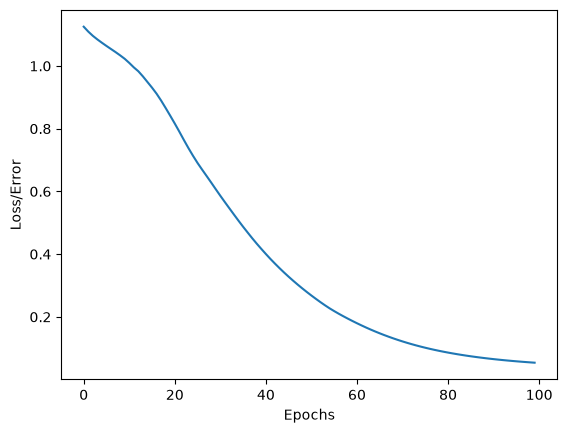

In [75]:
# Graphics 
plt.plot(range(epochs), losses)
plt.xlabel("Epochs")
plt.ylabel("Loss/Error")

In [77]:
# Evalute Model on Test Data Set (validate model on test set)
with torch.no_grad(): # Basically turn off back propogation
    y_eval = model.forward(X_test)      # X_test are features from our test set, y_eval are predictions 
    loss = criterion(y_eval, y_test)    # Find the loss or error
loss
#! Its only 0.13, and our last error was 0.06, there are not ~

tensor(0.1315)

In [84]:
correct = 0
with torch.no_grad():
    for i, data in enumerate(X_test):
        y_eval = model.forward(data)
        
        # Will tell us what type of flower class our network thinks it is
        print(f'{i+1}.) {str(y_eval)} \t {y_test[i]}')
        
        # Correct or not
        if y_eval.argmax().item() == y_test[i]:
            correct += 1
            
print(f'We got {correct} correct') 

1.) tensor([-5.8771,  4.4629,  6.5155]) 	 2
2.) tensor([-7.5451,  4.1668,  9.7293]) 	 2
3.) tensor([-8.4517,  5.1275, 10.2015]) 	 2
4.) tensor([-4.3411,  5.6280,  2.5636]) 	 1
5.) tensor([-7.1838,  4.8757,  8.3023]) 	 2
6.) tensor([-3.3940,  5.3421,  1.2802]) 	 1
7.) tensor([-5.9240,  4.9826,  6.0025]) 	 2
8.) tensor([-4.2895,  5.7016,  2.3920]) 	 1
9.) tensor([-6.5369,  4.9261,  7.1291]) 	 2
10.) tensor([-8.0526,  4.4129, 10.3325]) 	 2
11.) tensor([-5.6775,  4.9505,  5.6248]) 	 2
12.) tensor([ 4.5748, -2.2579, -2.8925]) 	 0
13.) tensor([ 4.2646, -2.0055, -2.7342]) 	 0
14.) tensor([-2.1081,  4.0482,  0.5803]) 	 1
15.) tensor([ 3.4608, -1.2147, -2.3488]) 	 0
16.) tensor([-5.4739,  5.1174,  5.0966]) 	 2
17.) tensor([ 4.0637, -1.8045, -2.6504]) 	 0
18.) tensor([-5.8090,  4.6057,  6.2494]) 	 1
19.) tensor([ 4.9250, -2.5763, -3.0545]) 	 0
20.) tensor([ 3.4559, -1.2559, -2.3637]) 	 0
21.) tensor([-2.6161,  4.5584,  0.8575]) 	 1
22.) tensor([-7.7427,  4.7379,  9.4233]) 	 2
23.) tensor([ 3.577